Libraries imported successfully!
Please upload your Gurgaon Real Estate CSV file.


Saving archive.zip to archive.zip

Uploaded file: archive.zip

Dataset loaded successfully!
Rows: 19515
Columns: 12

Column Names:
['Price', 'Status', 'Area', 'Rate per sqft', 'Property Type', 'Locality', 'Builder Name', 'RERA Approval', 'BHK_Count', 'Socity', 'Company Name', 'Flat Type']


,Price,Status,Area,Rate per sqft,Property Type,Locality,Builder Name,RERA Approval,BHK_Count,Socity,Company Name,Flat Type
0,10700000.0,Under Construction,1138,"9,450",2 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,home,Approved by RERA,2.0,M3M Antalya Hills Phase I,M3M,Apartment
1,14400000.0,Under Construction,1528,"9,450",3 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,Property In Gurgaon,Approved by RERA,3.0,M3M Antalya Hills Phase I,M3M,Apartment
2,10700000.0,Under Construction,1138,"9,450",2 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,properties for sale in Gurgaon,Approved by RERA,2.0,M3M Antalya Hills Phase I,M3M,Apartment
3,40000000.0,Ready to move,4500,"8,888",4 BHK Independent Floor,Sector 57,MM India Pvt Ltd,Not approved by RERA,4.0,Outside Socity,Outside,Plot
4,24000000.0,Under Construction,1800,"13,333",3 BHK Independent Floor in Anant Raj Estate Plots,Sector 63,MM India Pvt Ltd,Approved by RERA,3.0,Anant Raj Estate Plots,Anant,Floor



========== DATASET INFORMATION ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19515 entries, 0 to 19514
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Price          19515 non-null  object 
 1   Status         19515 non-null  object 
 2   Area           19515 non-null  int64  
 3   Rate per sqft  19515 non-null  object 
 4   Property Type  19515 non-null  object 
 5   Locality       19515 non-null  object 
 6   Builder Name   19515 non-null  object 
 7   RERA Approval  19515 non-null  object 
 8   BHK_Count      19515 non-null  float64
 9   Socity         19515 non-null  object 
 10  Company Name   19515 non-null  object 
 11  Flat Type      19515 non-null  object 
dtypes: float64(1), int64(1), object(10)
memory usage: 1.8+ MB

========== MISSING VALUES ==========
No missing values found.

========== DUPLICATE ROWS ==========
Duplicate rows: 5292

Dataset shape after removing duplicates: (1422

,price
count,1.422300e+04
mean,3.995377e+07
std,5.755291e+07
min,9.500000e+04
25%,1.410000e+07
50%,2.620000e+07
75%,4.550000e+07
max,1.226300e+09



========== EXPLORATORY DATA ANALYSIS ==========


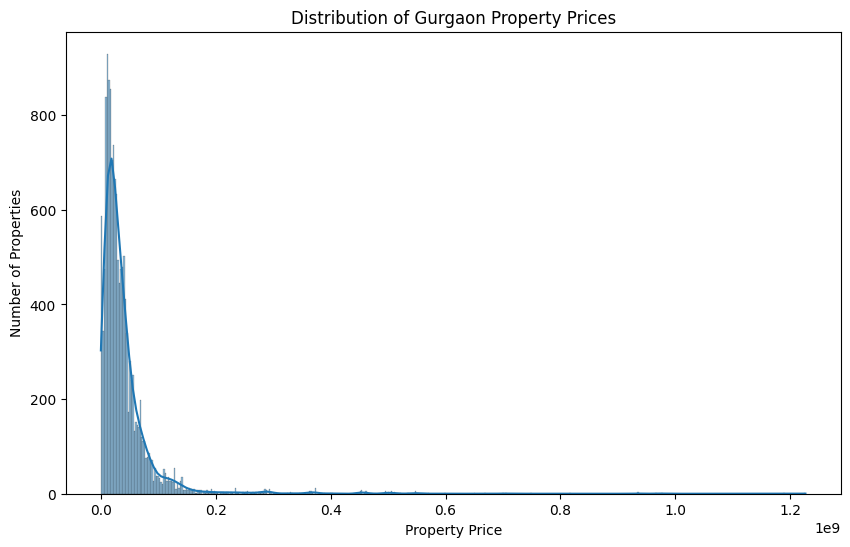

Detected area column: area


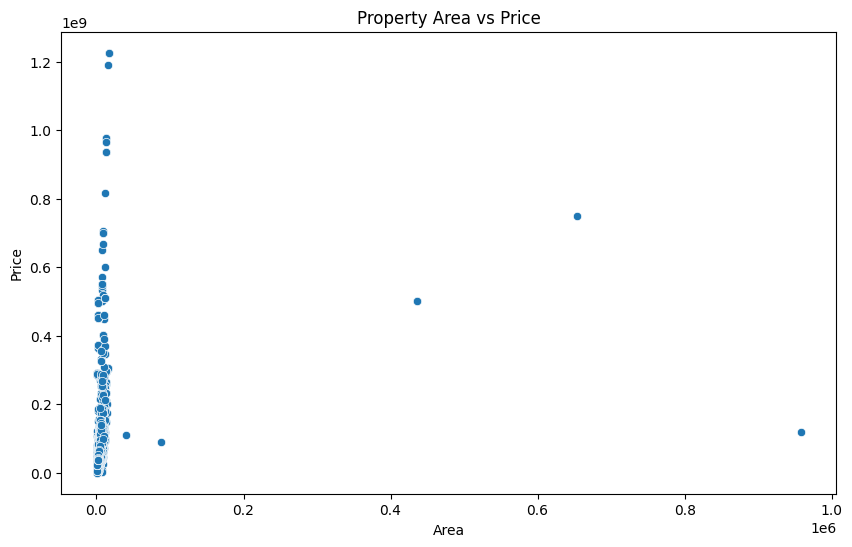

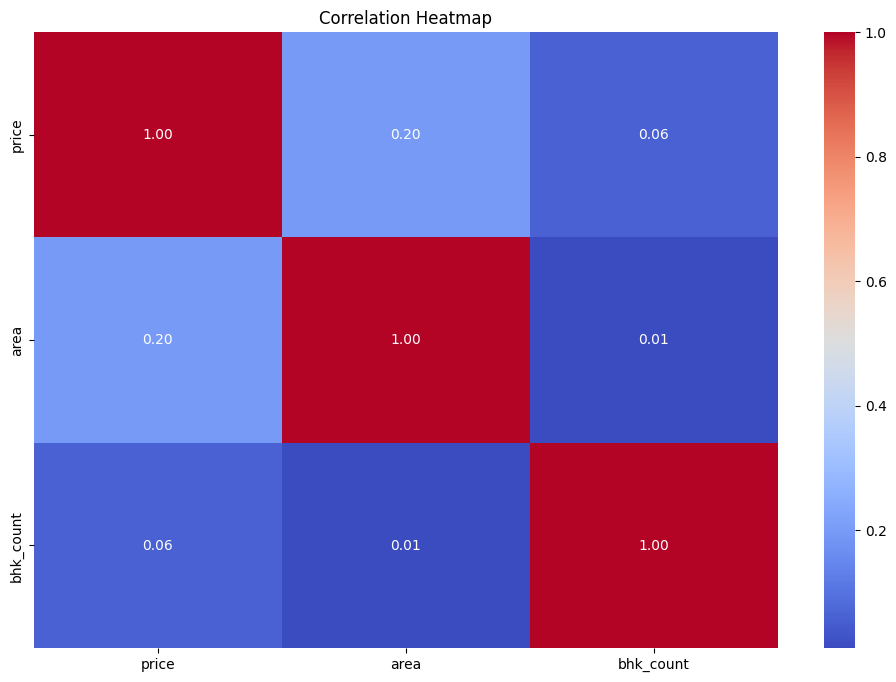


========== MACHINE LEARNING ==========

Numerical features:
['area', 'bhk_count']

Categorical features:
['status', 'rate_per_sqft', 'property_type', 'locality', 'builder_name', 'rera_approval', 'socity', 'company_name', 'flat_type']

Training rows: 11378
Testing rows: 2845

Training: Linear Regression


In [ ]:
# ============================================================
# GURGAON REAL ESTATE PRICE PREDICTION
# MACHINE LEARNING REGRESSION PROJECT
# ============================================================

# =========================
# 1. IMPORT LIBRARIES
# =========================

from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

print("Libraries imported successfully!")


# =========================
# 2. UPLOAD DATASET
# =========================

print("Please upload your Gurgaon Real Estate CSV file.")

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

print("\nUploaded file:", file_name)


# =========================
# 3. LOAD DATASET
# =========================

df = pd.read_csv(file_name)

print("\nDataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

display(df.head())


# =========================
# 4. BASIC INFORMATION
# =========================

print("\n========== DATASET INFORMATION ==========")

df.info()

print("\n========== MISSING VALUES ==========")

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) > 0:
    display(missing)
else:
    print("No missing values found.")


print("\n========== DUPLICATE ROWS ==========")

print("Duplicate rows:", df.duplicated().sum())


# =========================
# 5. REMOVE DUPLICATES
# =========================

df = df.drop_duplicates().reset_index(drop=True)

print("\nDataset shape after removing duplicates:", df.shape)


# =========================
# 6. CLEAN COLUMN NAMES
# =========================

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace(r"[^\w]", "_", regex=True)
)

print("\nCleaned column names:")
print(df.columns.tolist())


# =========================
# 7. FIND PRICE COLUMN
# =========================

possible_price_columns = [
    "price",
    "property_price",
    "selling_price",
    "sale_price",
    "price_in_cr",
    "price_in_crore",
    "price_in_lakh",
    "price_lakh",
    "price_cr"
]

price_column = None

for col in possible_price_columns:
    if col in df.columns:
        price_column = col
        break

# If exact names are not found, search for columns containing price
if price_column is None:
    price_matches = [
        col for col in df.columns
        if "price" in col or "cost" in col
    ]

    if len(price_matches) > 0:
        price_column = price_matches[0]

print("\nDetected target column:", price_column)


# =========================
# 8. PRICE COLUMN CHECK
# =========================

if price_column is None:
    print("\nERROR: Price column could not be detected.")
    print("Available columns are:")
    print(df.columns.tolist())
    raise ValueError(
        "Please check the dataset and set the correct price column manually."
    )


# =========================
# 9. CONVERT PRICE TO NUMERIC
# =========================

def convert_price(value):

    if pd.isna(value):
        return np.nan

    value = str(value).lower().strip()

    # Remove commas and currency symbols
    value = value.replace(",", "")
    value = value.replace("₹", "")
    value = value.replace("rs.", "")
    value = value.replace("rs", "")

    # Crore
    if "crore" in value or "cr" in value:
        try:
            number = float(
                value.replace("crore", "")
                     .replace("cr", "")
                     .strip()
            )
            return number * 100
        except:
            return np.nan

    # Lakh
    if "lakh" in value or "lac" in value:
        try:
            number = float(
                value.replace("lakh", "")
                     .replace("lac", "")
                     .strip()
            )
            return number
        except:
            return np.nan

    # Try normal number
    try:
        return float(value)
    except:
        return np.nan


df[price_column] = df[price_column].apply(convert_price)


# Remove rows where price is missing
df = df.dropna(subset=[price_column]).reset_index(drop=True)

print("\nPrice column cleaned successfully.")

print("\nPrice statistics:")
display(df[price_column].describe())


# =========================
# 10. EXPLORATORY DATA ANALYSIS
# =========================

print("\n========== EXPLORATORY DATA ANALYSIS ==========")

# Price distribution
plt.figure(figsize=(10, 6))

sns.histplot(
    df[price_column],
    kde=True
)

plt.title("Distribution of Gurgaon Property Prices")
plt.xlabel("Property Price")
plt.ylabel("Number of Properties")
plt.show()


# =========================
# 11. FIND AREA COLUMN
# =========================

possible_area_columns = [
    "area",
    "built_up_area",
    "builtup_area",
    "super_area",
    "carpet_area",
    "total_area",
    "sqft",
    "square_feet",
    "property_area"
]

area_column = None

for col in possible_area_columns:
    if col in df.columns:
        area_column = col
        break

if area_column is None:

    area_matches = [
        col for col in df.columns
        if "area" in col or "sqft" in col
    ]

    if len(area_matches) > 0:
        area_column = area_matches[0]

print("Detected area column:", area_column)


# =========================
# 12. AREA VS PRICE
# =========================

if area_column is not None:

    df[area_column] = (
        df[area_column]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.extract(r"(\d+\.?\d*)")[0]
        .astype(float)
    )

    temp = df[[area_column, price_column]].dropna()

    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        data=temp,
        x=area_column,
        y=price_column
    )

    plt.title("Property Area vs Price")
    plt.xlabel("Area")
    plt.ylabel("Price")

    plt.show()

else:
    print("Area column not found. Area graph skipped.")


# =========================
# 13. NUMERICAL CORRELATION
# =========================

numeric_df = df.select_dtypes(include=np.number)

if numeric_df.shape[1] >= 2:

    plt.figure(figsize=(12, 8))

    sns.heatmap(
        numeric_df.corr(),
        annot=True,
        cmap="coolwarm",
        fmt=".2f"
    )

    plt.title("Correlation Heatmap")

    plt.show()


# =========================
# 14. PREPARE DATA FOR ML
# =========================

print("\n========== MACHINE LEARNING ==========")

# Remove target from features
X = df.drop(columns=[price_column])
y = df[price_column]


# Remove columns that are mostly unique IDs
for col in X.columns:

    unique_ratio = X[col].nunique() / len(X)

    if unique_ratio > 0.95:

        print("Removing high-cardinality column:", col)

        X = X.drop(columns=[col])


# Separate numerical and categorical columns

numeric_features = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()


print("\nNumerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)


# =========================
# 15. PREPROCESSING
# =========================

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)


categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ],
    remainder="drop"
)


# =========================
# 16. TRAIN TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining rows:", len(X_train))
print("Testing rows:", len(X_test))


# =========================
# 17. CREATE MODELS
# =========================

models = {

    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42,
        max_depth=15,
        min_samples_split=5
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        max_depth=20,
        min_samples_split=2
    )
}


# =========================
# 18. TRAIN MODELS
# =========================

results = []

trained_models = {}


for model_name, model in models.items():

    print("\nTraining:", model_name)

    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                model
            )
        ]
    )

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    results.append(
        {
            "Model": model_name,
            "MAE": mae,
            "RMSE": rmse,
            "R2 Score": r2
        }
    )

    trained_models[model_name] = pipeline

    print("MAE:", round(mae, 4))
    print("RMSE:", round(rmse, 4))
    print("R2 Score:", round(r2, 4))


# =========================
# 19. MODEL COMPARISON
# =========================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)

print("\n========== MODEL COMPARISON ==========")

display(results_df)


# =========================
# 20. BEST MODEL
# =========================

best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

print("\n========================================")
print("BEST MODEL:", best_model_name)
print("========================================")

print(
    "R2 Score:",
    round(results_df.iloc[0]["R2 Score"], 4)
)

print(
    "MAE:",
    round(results_df.iloc[0]["MAE"], 4)
)

print(
    "RMSE:",
    round(results_df.iloc[0]["RMSE"], 4)
)


# =========================
# 21. ACTUAL VS PREDICTED
# =========================

best_predictions = best_model.predict(X_test)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=y_test,
    y=best_predictions
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title(
    "Actual vs Predicted Property Prices - "
    + best_model_name
)

plt.show()


# =========================
# 22. RESIDUAL ANALYSIS
# =========================

residuals = y_test - best_predictions

plt.figure(figsize=(10, 6))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Residual Distribution")

plt.xlabel("Prediction Error")

plt.show()


# =========================
# 23. SAVE RESULTS
# =========================

results_df.to_csv(
    "model_results.csv",
    index=False
)

print("\nModel results saved as: model_results.csv")


# =========================
# 24. SAVE CLEANED DATA
# =========================

df.to_csv(
    "cleaned_gurgaon_real_estate.csv",
    index=False
)

print(
    "Cleaned dataset saved as: "
    "cleaned_gurgaon_real_estate.csv"
)


# =========================
# 25. DOWNLOAD RESULTS
# =========================

files.download("model_results.csv")

print("\nPROJECT COMPLETED SUCCESSFULLY!")
print("Best Model:", best_model_name)